# Load libraries

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset

In [6]:
iris = load_iris()

In [7]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [8]:
X = iris["data"]
y = iris["target"]

### Convert it into a pandas DataFrame.

In [9]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

In [11]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


# Exploratory Data Analysis (EDA)

### Dataset Shape

In [12]:
df.shape

(150, 5)

### Data Types

In [13]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

### Missing values

In [14]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

### Descriptive Statistics

In [15]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Count Species Distribution

In [16]:
df["species"].value_counts()

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

# Data Visualization

### Pairplot

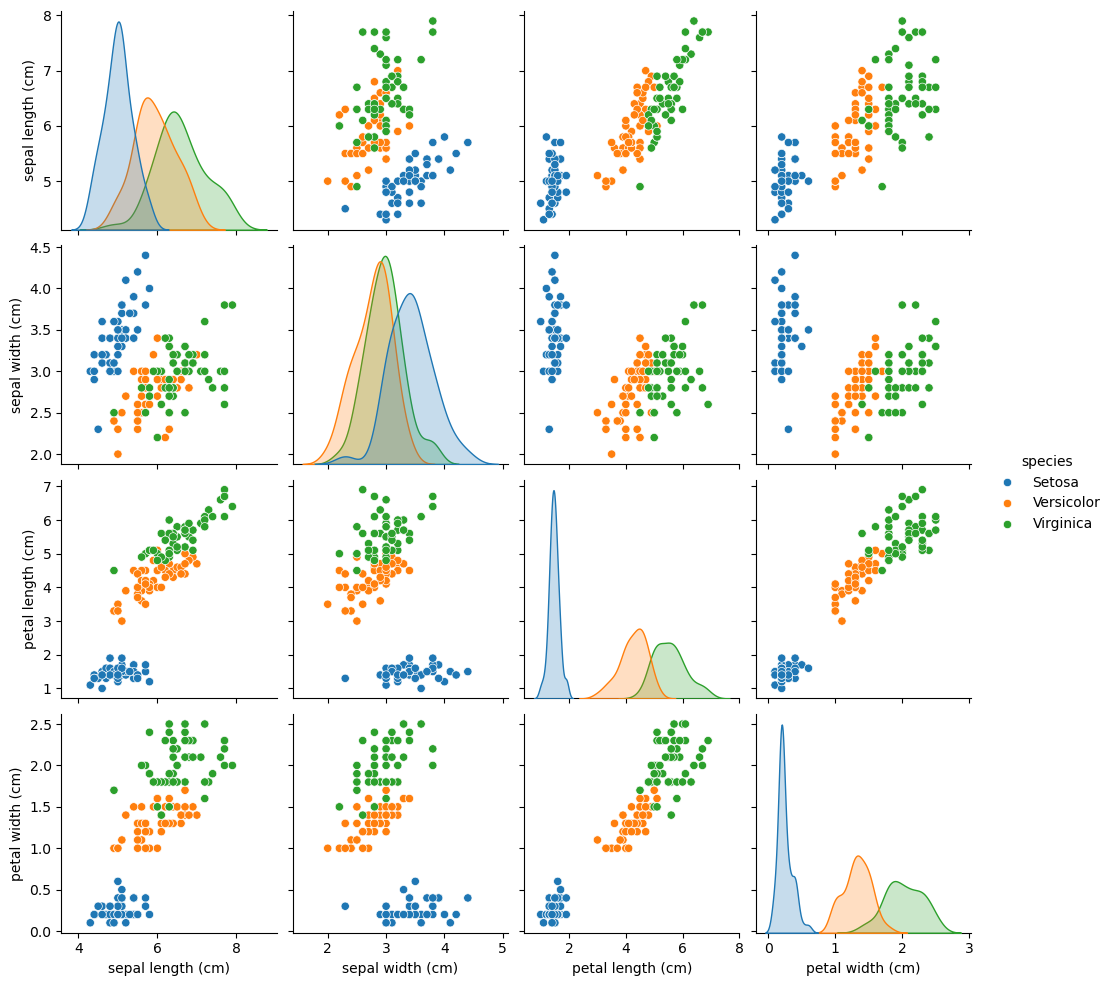

In [17]:
sns.pairplot(df, hue="species")
plt.show()

### Box Plots

In [18]:
features = iris.feature_names

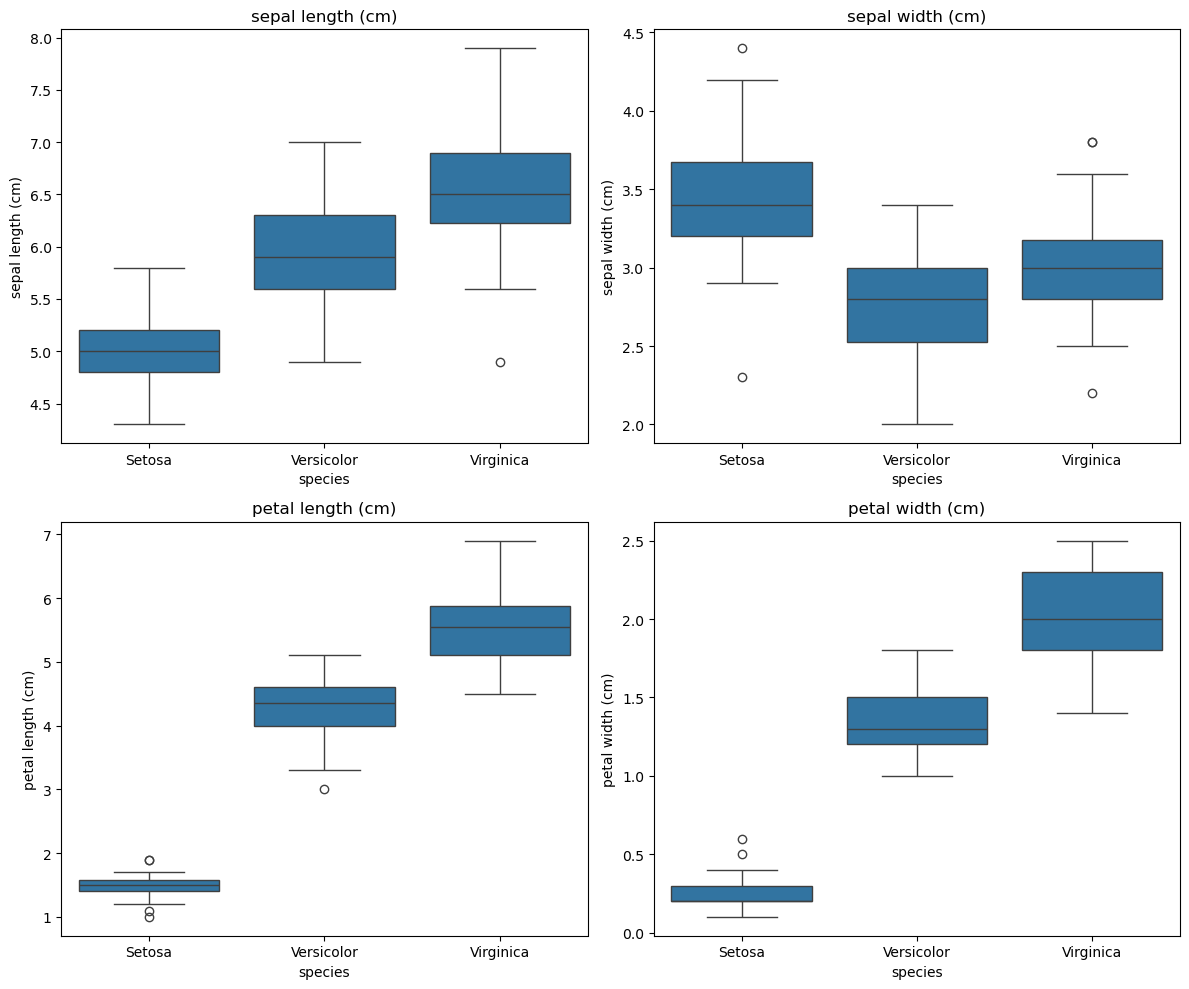

In [19]:
fig, axs = plt.subplots(2,2, figsize = (12,10))

sns.boxplot(x="species", y=features[0], ax= axs[0,0], data=df)
axs[0,0].set_title(features[0])

sns.boxplot(x="species", y=features[1], ax= axs[0,1], data=df)
axs[0,1].set_title(features[1])

sns.boxplot(x="species", y=features[2], ax= axs[1,0], data=df)
axs[1,0].set_title(features[2])

sns.boxplot(x="species", y=features[3], ax= axs[1,1], data=df)
axs[1,1].set_title(features[3])

plt.tight_layout()
#plt.set_title("Plot to show differences among species by physical features")
plt.show()

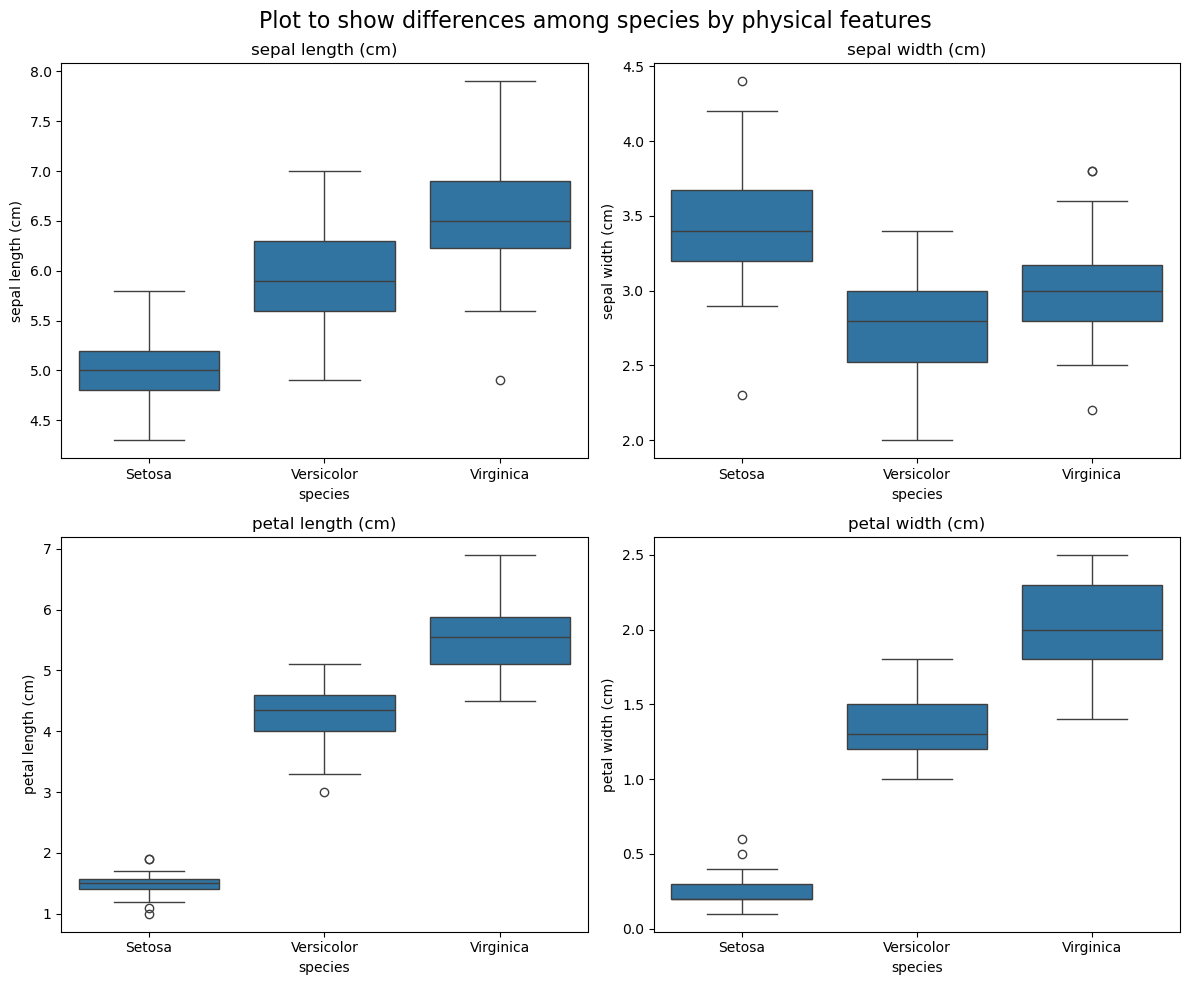

In [20]:
fig, axs = plt.subplots(2,2, figsize = (12,10))

axes = axs.flatten()
plt.suptitle("Plot to show differences among species by physical features", fontsize=16)

for i in range(len(features)):
    sns.boxplot(x="species", y=features[i], ax = axes[i], data=df)
    axes[i].set_title(features[i])

plt.tight_layout()
plt.show()

## Prepare Features and Labels

In [21]:
X = df.drop("species", axis=1)
y = df["species"]

In [22]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Models

## Model 1: Logistic Regression

In [23]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [24]:
lr_pred = lr.predict(X_test)

## Model 2: K-Nearest Neighbours

In [25]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [26]:
knn_pred = knn.predict(X_test)

## Model 3: Random Forest

In [27]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
rf_pred = rf.predict(X_test)

# Evaluate Models

### Accuracy score

In [29]:
model_evalaution = [lr_pred, knn_pred, rf_pred]

In [30]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random forest"],
    "Accuracy": [accuracy_score(y_test, pred) for pred in model_evalaution]
})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,1.0
1,KNN,1.0
2,Random forest,1.0


### Classification reports

In [31]:
for i, pred in enumerate(model_evalaution):
    print(results.Model[i])
    print("-"*55)
    print(classification_report(y_test, pred))
    print("="*55)
    print()

Logistic Regression
-------------------------------------------------------
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


KNN
-------------------------------------------------------
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Random forest
-------------------------------------------------------
              precision    rec

### Confusion matrix

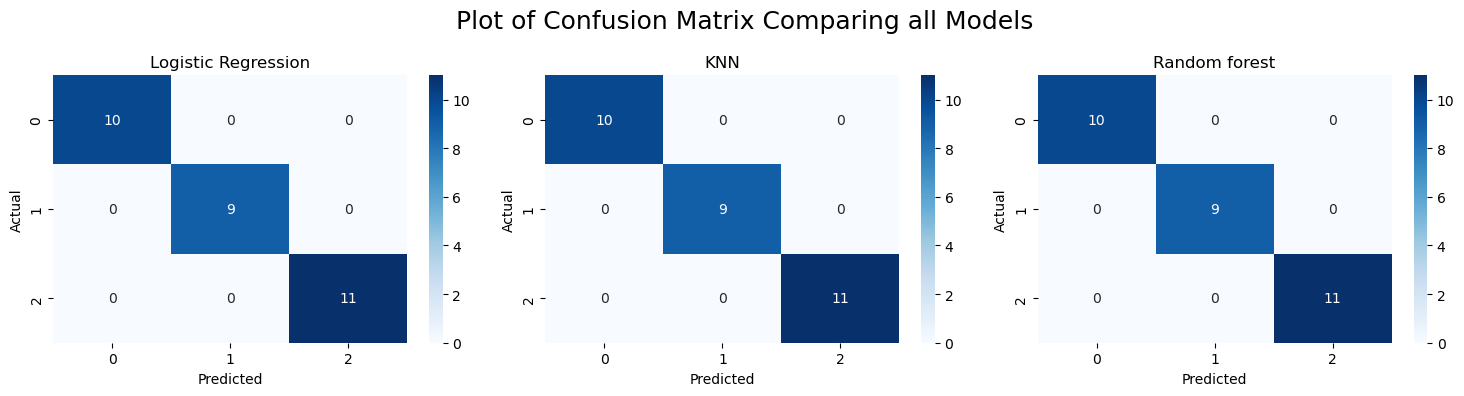

In [33]:
fig, axs = plt.subplots(1,3, figsize = (15,4))

plt.suptitle("Plot of Confusion Matrix Comparing all Models", fontsize=18)

for i, pred in enumerate(model_evalaution):
    cm = confusion_matrix(y_test, lr_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax = axs[i])

    axs[i].set_title(results.Model[i])
    axs[i].set_xlabel("Predicted")
    axs[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Conclusion

The 3 models are performing quite all right (equally) with this data.